## Developer details:


>**Name**: Rahul Biswas<br>**Course**: M.Tech Semester 1 <br> **University of Calcutta**



## Source code

In [2]:
import pandas as pd                 #For data manipulation
import numpy as np                  #For mathematical operations
import matplotlib.pyplot as plt     #For data visualization

In [5]:
data = pd.read_csv('/content/regression.csv')
data.head(10)                       #Display the first 10 rows of the dataset

,x,y
0,3.037865,5.434206
1,5.598591,14.954162
2,6.750278,7.494168
3,14.809892,26.702847
4,16.443458,26.869849
5,16.445845,51.414473
6,19.000672,37.866371
7,19.157046,27.736984
8,20.767704,49.760858
9,22.021572,31.834707


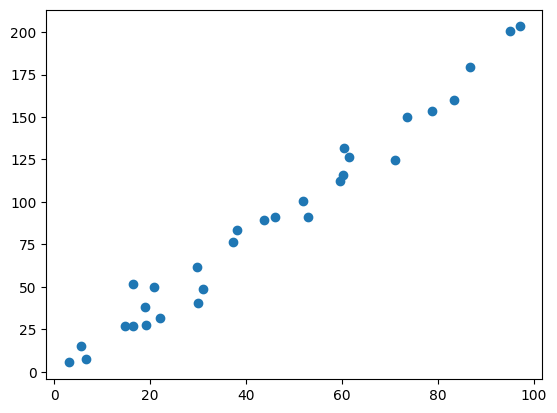

In [6]:
plt.scatter(data.x,data.y)        #Scatterplot visualization of data
plt.show()

In [11]:
#Define cost function(in this case MSE)
def mse(m, c, points):
  total_error = 0
  for i in range(len(points)):

    x = points.iloc[i].x
    y = points.iloc[i].y

    total_error += (y-(m*x+c))**2
  return total_error/float(len(points))

In [16]:
#Define the gradient descent of cost function
def gradient_descent(m_now, c_now, l, points):
  m_gradient = 0
  c_gradient = 0

  n = len(points)

  for i in range(n):
      x = points.iloc[i].x
      y = points.iloc[i].y

      m_gradient += -(2/n) * x * (y - (m_now * x + c_now))
      c_gradient += -(2/n) * (y - (m_now * x + c_now))

  m = m_now - m_gradient * l
  c = c_now - c_gradient * l
  return m, c

Epoch 0: m = 0.0108, b = 0.0002, Loss = 10747.4568
Epoch 50: m = 0.4841, b = 0.0078, Loss = 6250.8430
Epoch 100: m = 0.8441, b = 0.0136, Loss = 3649.7950
Epoch 150: m = 1.1178, b = 0.0179, Loss = 2145.2293
Epoch 200: m = 1.3261, b = 0.0212, Loss = 1274.9194
Epoch 250: m = 1.4844, b = 0.0237, Loss = 771.4921
Epoch 300: m = 1.6049, b = 0.0256, Loss = 480.2865
Epoch 350: m = 1.6965, b = 0.0270, Loss = 311.8398
Epoch 400: m = 1.7661, b = 0.0280, Loss = 214.4024
Epoch 450: m = 1.8191, b = 0.0288, Loss = 158.0401
Epoch 500: m = 1.8594, b = 0.0293, Loss = 125.4374
Epoch 550: m = 1.8901, b = 0.0297, Loss = 106.5785
Epoch 600: m = 1.9134, b = 0.0300, Loss = 95.6696
Epoch 650: m = 1.9311, b = 0.0302, Loss = 89.3592
Epoch 700: m = 1.9446, b = 0.0304, Loss = 85.7090
Epoch 750: m = 1.9549, b = 0.0304, Loss = 83.5975
Epoch 800: m = 1.9627, b = 0.0305, Loss = 82.3760
Epoch 850: m = 1.9686, b = 0.0305, Loss = 81.6693
Epoch 900: m = 1.9731, b = 0.0304, Loss = 81.2605
Epoch 950: m = 1.9765, b = 0.0304, 

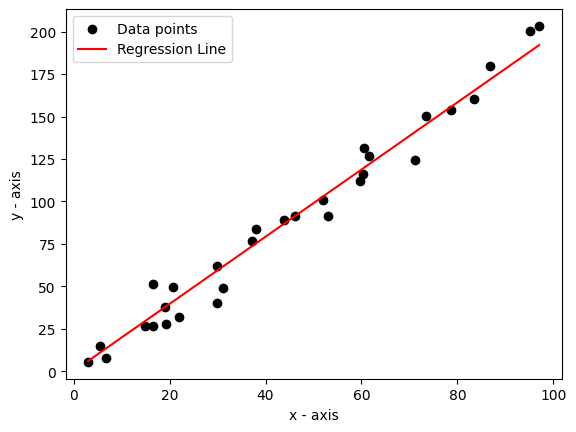

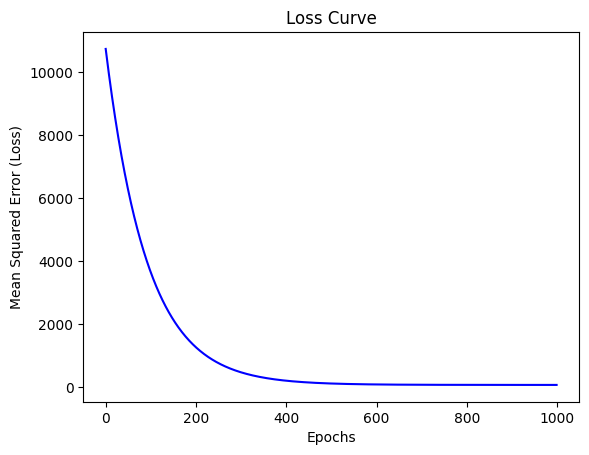

In [35]:
# -------------------------
# MAIN TRAINING LOOP
# -------------------------
m = 0
b = 0
L = 0.000001   # learning rate
epochs = 1000
losses = []  # store loss for plotting

for i in range(epochs):
    m, b = gradient_descent(m, b, L, data)
    loss = mse(m, b, data)
    losses.append(loss)

    if i % 50 == 0:
        print(f"Epoch {i}: m = {m:.4f}, b = {b:.4f}, Loss = {loss:.4f}")

print("Final slope (m):", m)
print("Final intercept (b):", b)

# -------------------------
# PLOT REGRESSION LINE
# -------------------------
plt.scatter(data.x, data.y, color="black", label="Data points")
# Generate 100 evenly spaced x-values between min and max x values
x_line = np.linspace(data.x.min(), data.x.max(), 100)

# Compute corresponding y-values using the trained model (y = m*x + b)
y_line = m * x_line + b
plt.plot(x_line, y_line, color="red", label="Regression Line")
plt.xlabel("x - axis")
plt.ylabel("y - axis")
plt.legend()
plt.show()

# -------------------------
# PLOT LOSS CURVE
# -------------------------
plt.plot(range(epochs), losses, color="blue")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Loss)")
plt.title("Loss Curve")
plt.show()